In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all('utils/modules/R/phasingtools')
library(argparse)
library(RColorBrewer)
library(stringr)


i Loading phasingtools

Loading required package: data.table

Loading required package: ggplot2

Loading required package: Hmisc

Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: 'Hmisc'


The following objects are masked from 'package:base':

    format.pval, units


Loading required package: stringr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_site.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_pos.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/extract_chunk_id.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/read_chunks_combined.R, and /gpfs3/well/lindgren-ukbb/projects/

In [2]:

main <- function(args){

    # parser
    print(args)
    stopifnot(dir.exists(args$in_dir_merged))

    # load files in directories
    dirs <- unlist(strsplit(args$in_dir, split = ','))
    dirs <- dirs[dirs != ""]
    #dirs[[1]] <- dirs[[1]][dirs[[1]] != ""]
    #print(dirs)
    stops <- lapply(dirs, function(dir) {
        if (!dir.exists(dir)) stop(paste0(dir, ' (directory) does not exist!'))
    })
    files <- unlist(lapply(dirs, function(d){list.files(d, pattern = 'trio', full.names = TRUE)}))

    # organize by filename, chunks and extension
    M <- as.data.frame(do.call(rbind, strsplit(basename(files), split = '\\.')))
    colnames(M) <- c('param','n','ext')
    datasets = unique(M$param)

    # read each file and calculate average contribution of chunk
    comparison <- do.call(rbind, lapply(datasets, function(dname){

      regex_bool <- paste0('^',dname)
      selected_files <- files[grepl(regex_bool, basename(files))]

      ds <- lapply(selected_files, function(f) {
            d <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
            d$chunk <- unlist(strsplit(str_match(f, ".of."), split = 'of'))[1]
            d$dataset <- dname
            d$chr <- str_extract(f, 'chr[0-9]+')
            return(d)
        })

      ds <- as.data.frame(do.call(rbind, ds))

      avg <- tail(ds)[1,]
      avg$n_tested <- sum(ds$n_tested)
      avg$n_switch <- sum(ds$n_switch)
      avg$n_mendel <- sum(ds$n_mendel)
      bconf <- Hmisc::binconf(avg$n_switch, avg$n_tested)
      est <- bconf[1]
      err <- abs(est - bconf[3])
      avg$ci_ser_est <- est
      avg$ci_ser_error <- err
      avg$ci_ser_est_pct <- NA
      avg$ci_ser_error_pct <- NA
      avg$chunk <- as.character('Average')

      ds <- rbind(ds, avg)

      return(ds)

    }))

    # get results from merged files
    # works only for chr20 for now!
    files_merge = list.files(args$in_dir_merged,
                   pattern = 'trio',
                   full.names = TRUE)

    dfs_merge <- do.call(rbind, lapply(files_merge, function(f){
        stopifnot(file.exists(f))
        merged <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))

        merged$dataset <- tools::file_path_sans_ext(basename(f))
        merged$chunk <- as.character("Merged")
        merged$chr <- str_extract(f, 'chr[0-9]+')
        return(merged)
    }))

    combined <- rbind(comparison, dfs_merge)

    max_chunks <- max(na.omit(as.numeric(as.character(combined$chunk))))
    myColors <- brewer.pal(max_chunks,"PiYG")
    myColors[10] <- 'grey'
    myColors[11] <- 'black'
    names(myColors) <- levels(combined$chunk)
    colScale <- scale_colour_manual(name = "chunk",values = myColors)

    # get values for vertical lines
    best_mrg <- combined[combined$chunk == 'Merged',]
    best_mrg <- best_mrg[best_mrg$ci_ser_est == min(best_mrg$ci_ser_est),]
    #best_avg <- combined[combined$chunk == 'Average',]
    #best_avg <- best_avg[best_avg$ci_ser_est == min(best_avg$ci_ser_est),]

    # convert into ordered factor (for plotting)
    combined$chunk <- factor(combined$chunk, levels = c(as.character(1:9),"Average","Merged"))
    combined$chr <- factor(combined$chr, levels = paste0("chr",1:22))

    # plot resulst
    pd <- position_dodge2(width = 0.6, preserve = "single")
    ggplot(combined,
           aes(
               y=100*ci_ser_est,
               ymax = 100*(ci_ser_est + ci_ser_error),
               ymin = 100*(ci_ser_est - ci_ser_error),
               x = chunk,
               fill = chunk
           )) +
        fillScale +
        geom_bar(stat='identity', color = 'black') +
        geom_hline(yintercept=best_lig$ci_ser_est*100, linetype = 'dashed', col = 'black', alpha = 0.8) +
        geom_hline(yintercept=worst_lig$ci_ser_est*100, linetype = 'dashed', col = 'black', alpha = 0.8) +
        geom_errorbar(stat='identity', position = pd, width = 0.4) +
        ggtitle('Phasing accuracy across chunks (UKBB Calls+WES)',
                'Dashed line indicate lowest and highest SERs observed. M = Merged, L = Ligated.') +
        labs(color = "Phasing chunk(s)") +
        ylab('Switch Errors (%)') + xlab('Chromosmal chunks') +
        theme_bw() +
        facet_wrap(~chr)

    #pd <- position_dodge(0.7)
    #plt <- ggplot(combined,
    #       aes(
    #           x=100*ci_ser_est,
    #           xmax = 100*(ci_ser_est + ci_ser_error),
    #           xmin = 100*(ci_ser_est - ci_ser_error),
    #           y = chr,
    #           color = chunk
    #       )) +
    #    colScale +
    #    geom_vline(xintercept=best_mrg$ci_ser_est*100, linetype = 'dashed', col = 'black') +
    #    #geom_vline(xintercept=best_avg$ci_ser_est*100, linetype = 'dashed', color = 'black') +
    #    geom_point(stat='identity', position = pd, size = 2) +
    #    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    #    ggtitle('Phasing accuracy across UKBB WES+CALLS',) +
    #    labs(color = "Phasing chunk(s)") +
    #    xlab('Switch Errors (%)') + ylab('') +
    #    theme_bw()

    # write out plot and table
    outfile_plt = paste0(args$out_prefix, ".pdf")
    outfile_tbl = paste0(args$out_prefix, ".tsv")
    fwrite(combined, outfile_tbl, sep = '\t')
    pdf(outfile_plt, width = args$img_width, height = args$img_height)
    print(plt)
    graphics.off()

    # write error rates by site
    outfile_sites <- paste0(args$out_prefix, "sites.pdf")
    pdf(outfile_sites, width = 10, height = 8)
    for (chr in 1:22){
        #chunk_dir <- "data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chrCHR-16xshort.qe"
        chunk_dir <- gsub("CHR",chr, args$chunk_dir)
        chunks <- read_chunks_from_dir(chunk_dir)

        ligated_files <- list.files(args$ligated_dir, full.names = TRUE, pattern = '[0-9]+.txt')
        ligated_file <- ligated_files[grepl(paste0("chr",chr,"-"), ligated_files)]
        ligated <- read_chunks_combined(ligated_file)
        ligated$chunk <- "ligated"

        merged_files <- list.files(args$merged_dir, full.names = TRUE, pattern = '[0-9]+.txt')
        merged_file <- merged_files[grepl(paste0("chr",chr,"-"), merged_files)]
        merged <- read_chunks_combined(merged_file)
        merged$chunk <- "ligated"

        mrg <- rbind(chunks, ligated, merged)
        max_chunks <- suppressWarnings(max(na.omit(as.numeric(as.character(mrg$chunk)))))
        mrg$chunk <- factor(mrg$chunk, levels = as.character(c(1:max_chunks, "merged","ligated")))

        #trim <- fread('data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr10_trims.txt')
        trim_files <- list.files(args$trim_dir, full.names = TRUE, pattern = '[0-9]+.txt')
        trim_file <- trim_files[grepl(paste0("chr",chr,"_"), trim_files)]
        trim <- fread(trim_file)
        colnames(trim) <- c('dir','prefix','i','mt1_right_flank',  'mt2_left_flank','o','start','end')
        trim$midpoint <- trim$mt1_right_flank-trim$mt2_left_flank

        colors <- brewer.pal(max_chunks,"Blues")
        colors[max_chunks + 1] <- 'orange'
        colors[max_chunks + 2] <- 'darkred'
        names(colors) <- levels(mrg$chunk)
        scale_color <- scale_colour_manual(name = "chunk",values = colors)

        plt <- ggplot(mrg, aes(x = POS, y = cumsum, group = chunk, color = chunk)) +
            geom_point(alpha = 0.8) +
            geom_line() +
            scale_color +
            annotate("rect", xmin = trim$mt2_left_flank, xmax = trim$mt1_right_flank,
                     ymin = -Inf, ymax = Inf, alpha = .2) +
            geom_vline(xintercept=trim$mt1_right_flank, linetype = 'dashed', color = 'black') +
            geom_vline(xintercept=trim$mt2_left_flank, linetype = 'dashed', color = 'black') +
            xlab("BP (genomic position)") +
            ylab("Cumulativ sum of Switch Errors") +
            theme_bw() +
            ggtitle(paste("Switch Errrors when ligating Chromosome", chr),
                    "Shaded regions indicate ligation variant overlap")

        print(plt)
     }
    graphics.off()


#ggplot(filename = outfile_plt, plot = plt, width = 8, height = 6)

}

In [3]:
args <- list(
    master_chunk_dir = "data/phased/wes_union_calls/chunks",
    ligated_dir = "data/phased/wes_union_calls/ligated"
)

In [21]:
files <- list.files(args$master_chunk_dir, recursive = TRUE, pattern = ".txt", full.names = TRUE)
stopifnot(length(files) > 0)
autosomes <- paste0("chr",1:22)

In [22]:
variants <- fread("/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list")

In [4]:
fread_phased_sites <- function(file, ...){
    
    # get details about chunks
    bname <- basename(file)
    chunk_current <- as.numeric(gsub("of","",stringr::str_extract(bname, "[0-9]+of")))
    chunk_final <- as.numeric(gsub("of","",stringr::str_extract(bname, "of[0-9]+")))
    method <- unlist(strsplit(bname, split = '_'))[1]
    phasing_region_size <- as.numeric(gsub("_prs","",stringr::str_extract(bname, "_prs[0-9]+")))
    phasing_overlap_size <- as.numeric(gsub("_pro","",stringr::str_extract(bname, "_pro[0-9]+")))
    max_phasing_region_size <- as.numeric(gsub("_mprs","",stringr::str_extract(bname, "_mprs[0-9]+")))
    
    # append to data.table
    d <- fread(file, ...)
    d$locus <- paste0(d$CHR,":",d$POS)
    d$chunk_current <- chunk_current
    d$chunk_final <- chunk_final
    d$method <- method
    d$phasing_region_size <- phasing_region_size
    d$phasing_overlap_size <- phasing_overlap_size
    d$max_phasing_region_size <- max_phasing_region_size
    return(d)
    
}

In [19]:

lst <- lapply(autosomes, function(chr){
    
    # subset by chromosome (if we read in all at the same time it takes too long)
    files_chr <- files[grepl(paste0(chr,"-"), files)]
    d <- data.table(do.call(rbind, lapply(files_chr, fread_phased_sites)))
    d$wes_variant <- d$locus %in% variants$locus
    
    # get counts
    counts <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})


In [20]:
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [21]:
colnames(counts)

[1] "wes_variant"   "chunk_current" "CHR"           "switches"     
[5] "tested"        "pointest"      "lower"         "upper"

In [22]:
pd <- position_dodge(0.7)
plt <- ggplot(counts,
       aes(
           y=100*pointest,
           ymax = 100*upper,
           ymin = 100*lower,
           x = factor(chunk_current), #factor(CHR, levels = autosomes),
           fill = factor(wes_variant)
       )) +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    #geom_point(stat='identity', position = pd, size = 2) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    labs(fill = "WES variant") +
    ylab('Switch Errors (%)') + xlab('') +
    theme_bw() +
    facet_wrap(~factor(CHR, levels = autosomes))

In [31]:
counts[which(counts$pointest == min(counts$pointest)),]

wes_variant,chunk_current,CHR,switches,tested,pointest,lower,upper
<lgl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
TRUE,3,chr19,2,36511,5.477801e-05,1.502224e-05,0.0001997249


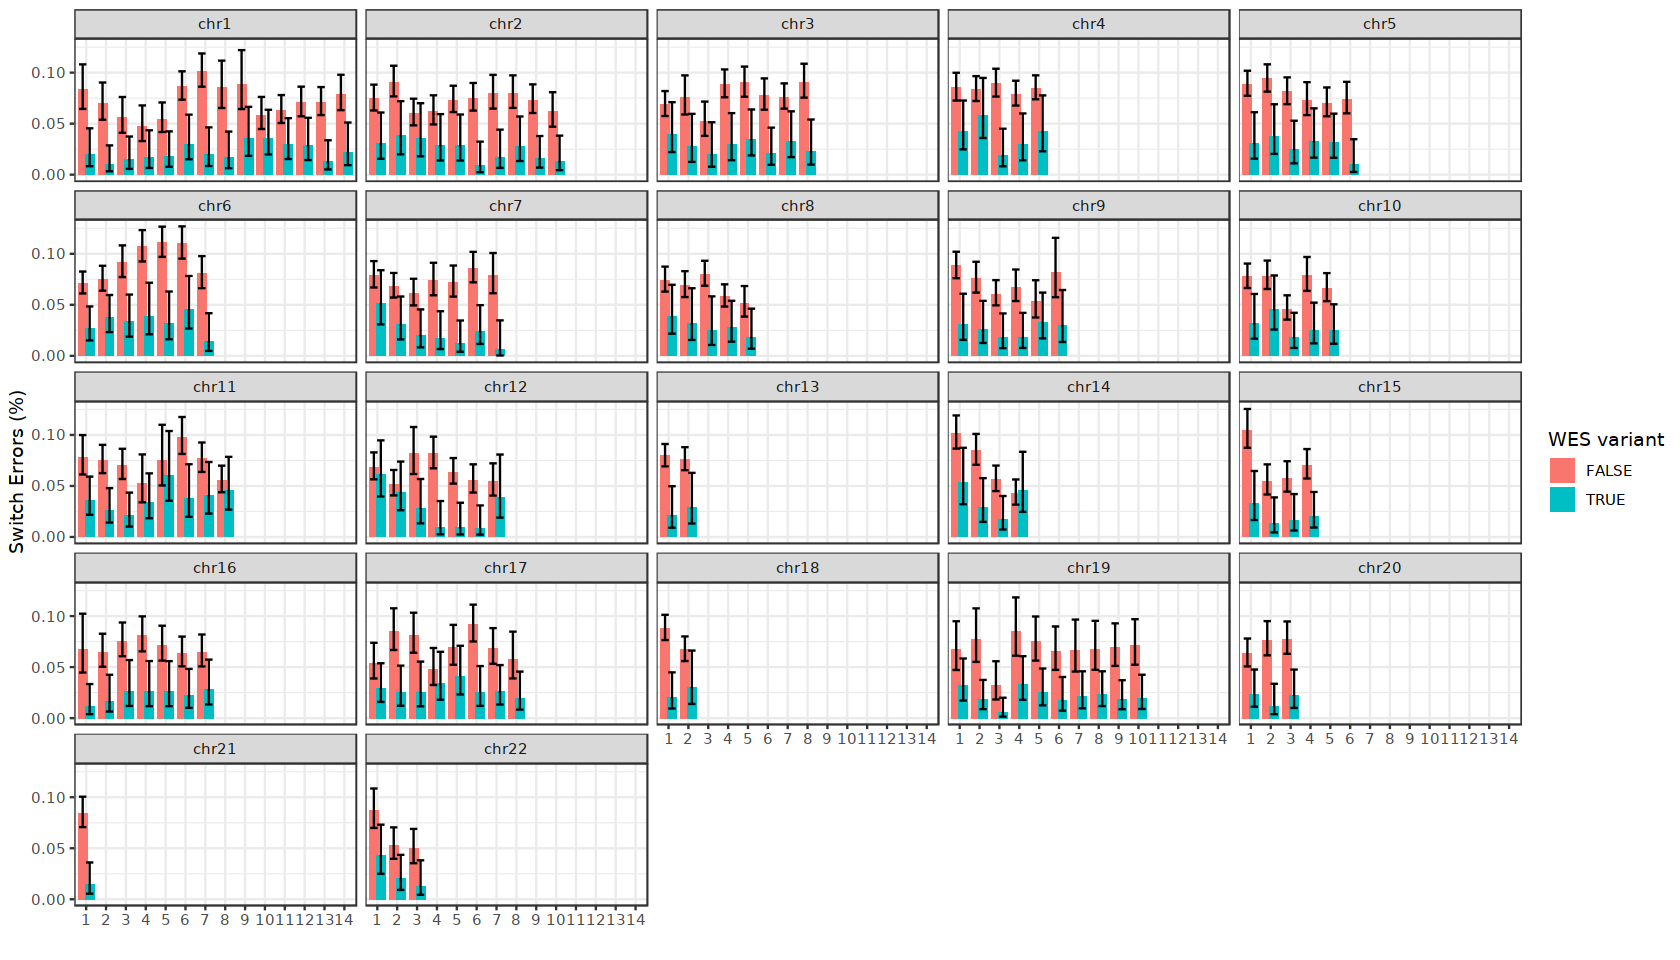

In [24]:
options(repr.plot.width=14, repr.plot.height=8)
plt

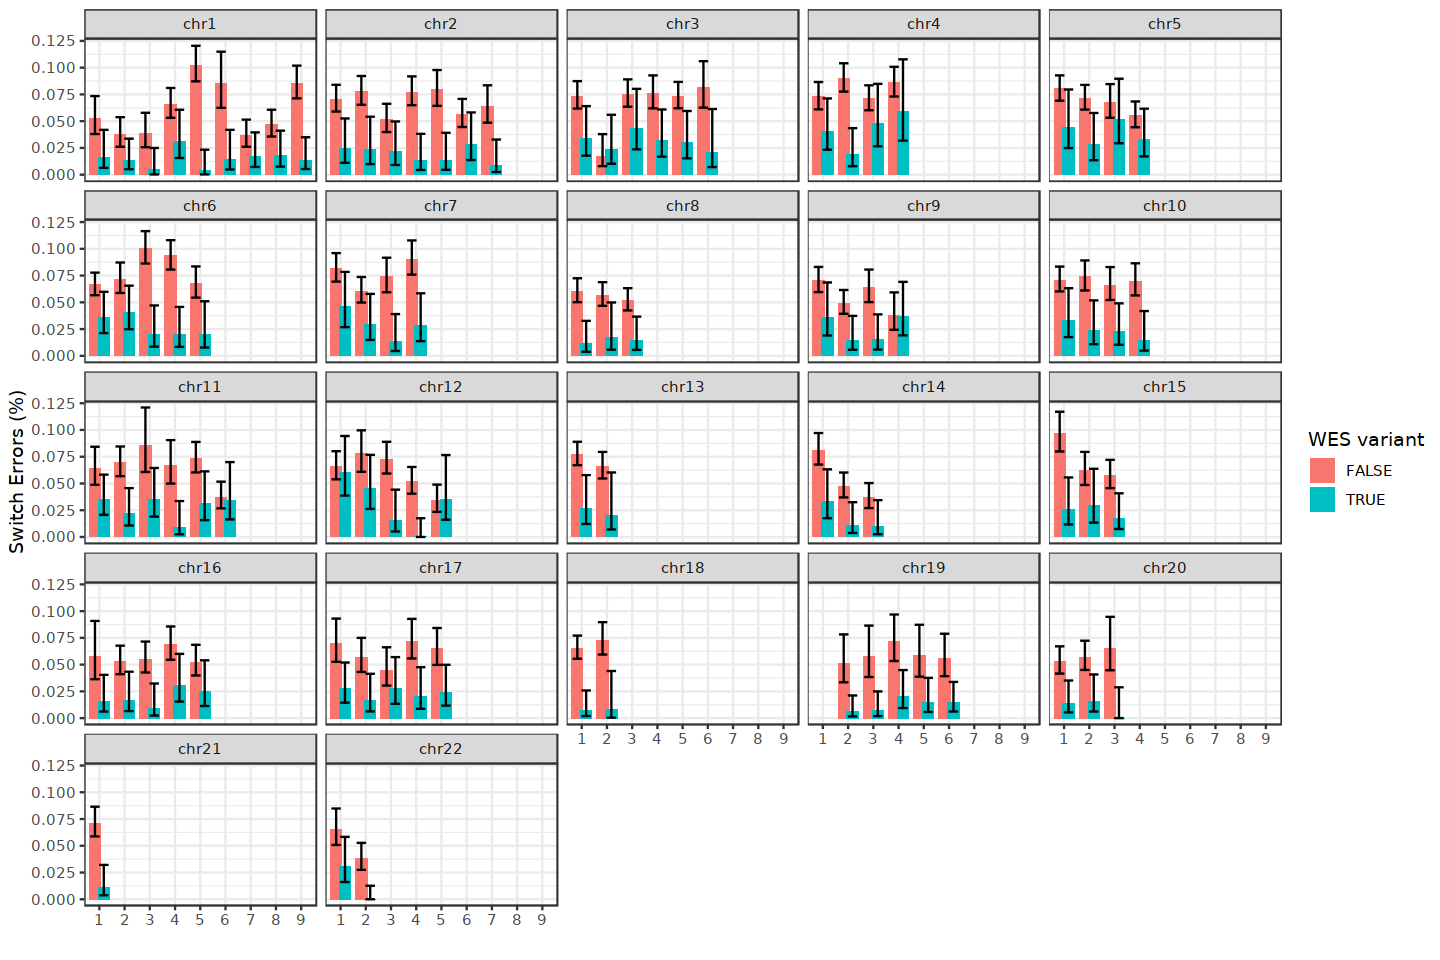

In [152]:
options(repr.plot.width=12, repr.plot.height=8)
plt

[1] "ID"                      "CHR"                    
 [3] "POS"                     "REF"                    
 [5] "ALT"                     "MAF"                    
 [7] "AF"                      "AC"                     
 [9] "AN"                      "HWE"                    
[11] "trio_id"                 "index"                  
[13] "switch"                  "switches"               
[15] "locus"                   "chunk_current"          
[17] "chunk_final"             "method"                 
[19] "phasing_region_size"     "phasing_overlap_size"   
[21] "max_phasing_region_size" "wes_variant"

In [ ]:
dim(d)

In [ ]:
fread_trios <- function(file, ...){
    
    
    # get details about chunks
    bname <- basename(file)
    chunk_current <- as.numeric(gsub("of","",stringr::str_extract(bname, "[0-9]+of")))
    chunk_final <- as.numeric(gsub("of","",stringr::str_extract(bname, "of[0-9]+")))
    method <- unlist(strsplit(bname, split = '_'))[1]
    phasing_region_size <- as.numeric(gsub("_prs","",stringr::str_extract(bname, "_prs[0-9]+")))
    phasing_overlap_size <- as.numeric(gsub("_pro","",stringr::str_extract(bname, "_pro[0-9]+")))
    max_phasing_region_size <- as.numeric(gsub("_mprs","",stringr::str_extract(bname, "_mprs[0-9]+")))
    
    # append to data.table
    d <- fread(file, ...)
    colnames(d) <- c(
        "family",
        "father",
        "mother",
        "child",
        "n_tested",
        "n_mendel",
        "n_switches",
        "switches_pct"
    )
    d$chunk_current <- chunk_current
    d$chunk_final <- chunk_final
    d$method <- method
    d$phasing_region_size <- phasing_region_size
    d$phasing_overlap_size <- phasing_overlap_size
    d$max_phasing_region_size <- max_phasing_region_size
    return(d)
    
}

In [34]:
files <- list.files(args$ligated_dir, pattern = ".txt", full.names = TRUE)
stopifnot(length(files) > 0)

In [70]:
d <- fread_phased_sites(files[2])
head(d)

ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,⋯,index,switch,switches,locus,chunk_current,chunk_final,method,phasing_region_size,phasing_overlap_size,max_phasing_region_size
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
.,chr10,47630,G,C,7.23981e-03,7.23981e-03,2891,399320,3.13546e-05,⋯,67,0,0,chr10:47630,NA,NA,ukb,NA,NA,NA
.,chr10,47630,G,C,7.23981e-03,7.23981e-03,2891,399320,3.13546e-05,⋯,67,0,0,chr10:47630,NA,NA,ukb,NA,NA,NA
.,chr10,47630,G,C,7.23981e-03,7.23981e-03,2891,399320,3.13546e-05,⋯,67,0,0,chr10:47630,NA,NA,ukb,NA,NA,NA
.,chr10,48003,A,G,4.50766e-05,4.50766e-05,18,399320,1.00000e+00,⋯,114,0,0,chr10:48003,NA,NA,ukb,NA,NA,NA
.,chr10,48601,C,A,3.74687e-02,3.74687e-02,14962,399320,0.00000e+00,⋯,149,0,0,chr10:48601,NA,NA,ukb,NA,NA,NA
.,chr10,48601,C,A,3.74687e-02,3.74687e-02,14962,399320,0.00000e+00,⋯,149,0,0,chr10:48601,NA,NA,ukb,NA,NA,NA


In [192]:
cuts <- c(1, 10^-(1:6))

In [193]:
d$maf_bin <- cut(d$MAF, breaks = cuts)
head(d$maf_bin)

[1] (0.001,0.01]   (0.001,0.01]   (0.001,0.01]   (1e-05,0.0001] (0.01,0.1]    
[6] (0.01,0.1]    
6 Levels: (1e-06,1e-05] (1e-05,0.0001] (0.0001,0.001] ... (0.1,1]

In [230]:
aggregate_by_chrom <- function(files){
    lst <- lapply(files, function(file){
        d <- fread_phased_sites(file)
        d$wes_variant <- d$locus %in% variants$locus
        counts <- aggregate(switches ~ wes_variant + CHR, data = d, FUN = sum)
        tested <- aggregate(switches ~ wes_variant + CHR, data = d, FUN = length)
        counts <- data.table(counts, tested = tested$switches)
        return(counts)
    })
    return(lst)
}

In [231]:
calc_binom_ci <- function(lst){
    counts <- do.call(rbind, lst)
    stopifnot(nrow(counts) > 0)
    counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
    colnames(counts_ci) <- tolower(colnames(counts_ci))
    counts <- cbind(counts, counts_ci)
    return(counts)
}

In [233]:
lst <- aggregate_by_chromsome(files)
counts <- calc_binom_ci(lst)

In [234]:
test

wes_variant,CHR,switches,tested,pointest,lower,upper
<lgl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
FALSE,chr1,498,729649,0.0006825200,6.251673e-04,0.0007451302
TRUE,chr1,45,199590,0.0002254622,1.685162e-04,0.0003016459
FALSE,chr10,321,470419,0.0006823704,6.117147e-04,0.0007611809
TRUE,chr10,22,84535,0.0002602472,1.718778e-04,0.0003940332
FALSE,chr11,328,458240,0.0007157821,6.424201e-04,0.0007975152
TRUE,chr11,48,137783,0.0003483739,2.627891e-04,0.0004618190
FALSE,chr12,293,454258,0.0006450079,5.752793e-04,0.0007231821
TRUE,chr12,32,97643,0.0003277245,2.321647e-04,0.0004625988
FALSE,chr13,247,331444,0.0007452239,6.579289e-04,0.0008440916


In [196]:
head(counts)

wes_variant,CHR,switches,tested,pointest,lower,upper
<lgl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
FALSE,chr1,498,729649,0.0006825200,0.0006251673,0.0007451302
TRUE,chr1,45,199590,0.0002254622,0.0001685162,0.0003016459
FALSE,chr10,321,470419,0.0006823704,0.0006117147,0.0007611809
TRUE,chr10,22,84535,0.0002602472,0.0001718778,0.0003940332
FALSE,chr11,328,458240,0.0007157821,0.0006424201,0.0007975152
TRUE,chr11,48,137783,0.0003483739,0.0002627891,0.0004618190


In [197]:
options(repr.plot.width=12, repr.plot.height=7)
pd <- position_dodge(0.7)
plt <- ggplot(counts,
       aes(
           y=factor(CHR, levels = autosomes),
           x=100*pointest,
           xmax = 100*upper,
           xmin = 100*lower,
           fill = factor(wes_variant)
       )) +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    geom_point(position = pd) +
    labs(fill = "WES variant") +
    xlab('Switch Errors (%)') + ylab('') +
    theme_bw()

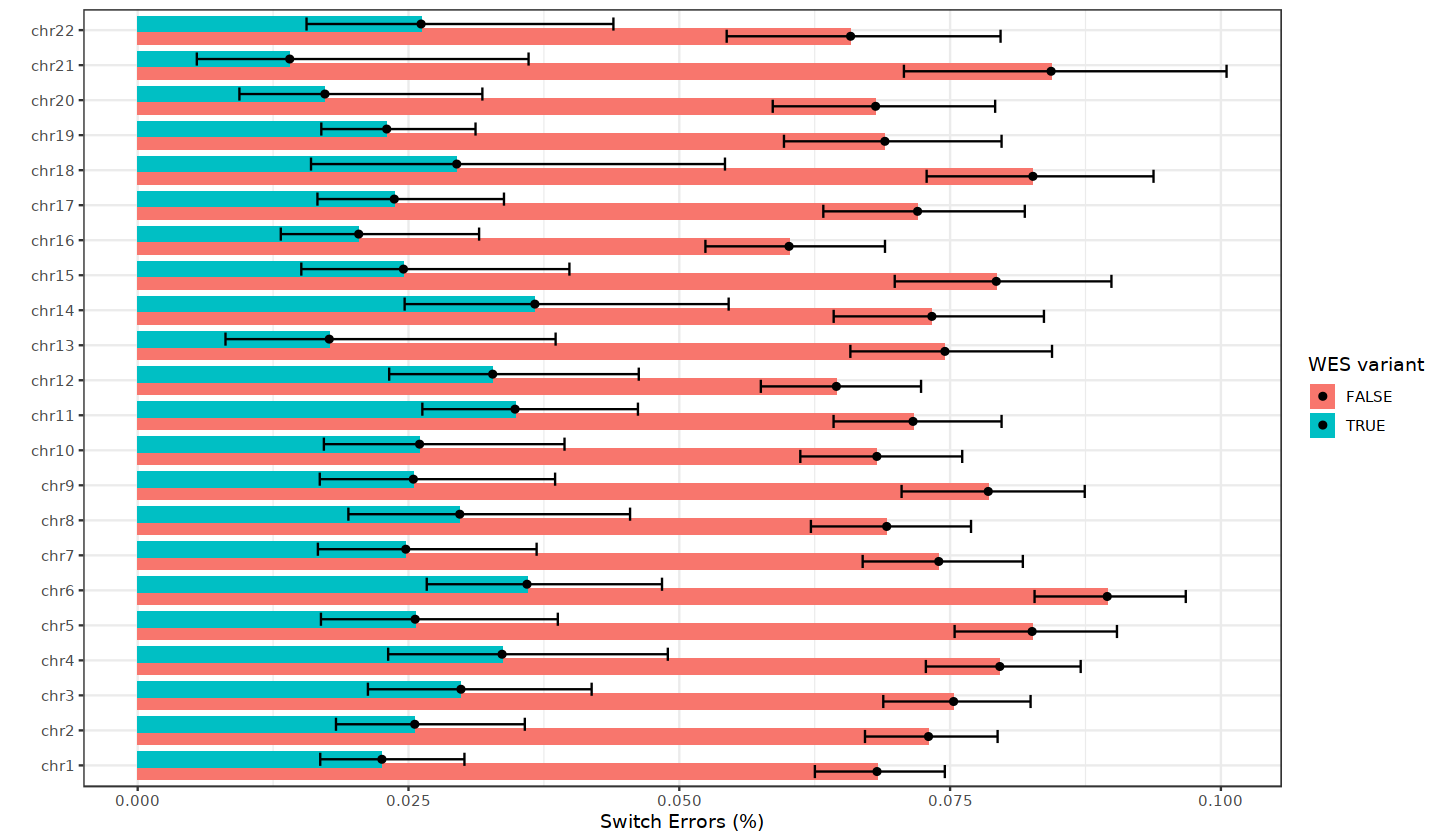

In [198]:
plt

In [208]:
lst <- lapply(files, function(file){
    
    d <- fread_phased_sites(file)
    d$wes_variant <- d$locus %in% variants$locus
    d$maf_bin <- cut(d$MAF, breaks = cuts)
    
    # get counts
    counts <- aggregate(switches ~ wes_variant + maf_bin + CHR, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + maf_bin + CHR, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})

In [211]:
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [224]:
pd <- position_dodge(0.7)
plt <- ggplot(counts[counts$wes_variant == TRUE, ],
       aes(
           x=100*pointest,
           xmax = 100*upper,
           xmin = 100*lower,
           y = maf_bin,
           fill = factor(wes_variant)
       )) +
    #geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_point(stat='identity', position = pd, size = 2) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    labs(fill = "WES variant") +
    ylab('Switch Errors (%)') + xlab('') +
    theme_bw() +
    facet_wrap(~factor(CHR, levels = autosomes)) +
    coord_cartesian(xlim=c(0, 2))

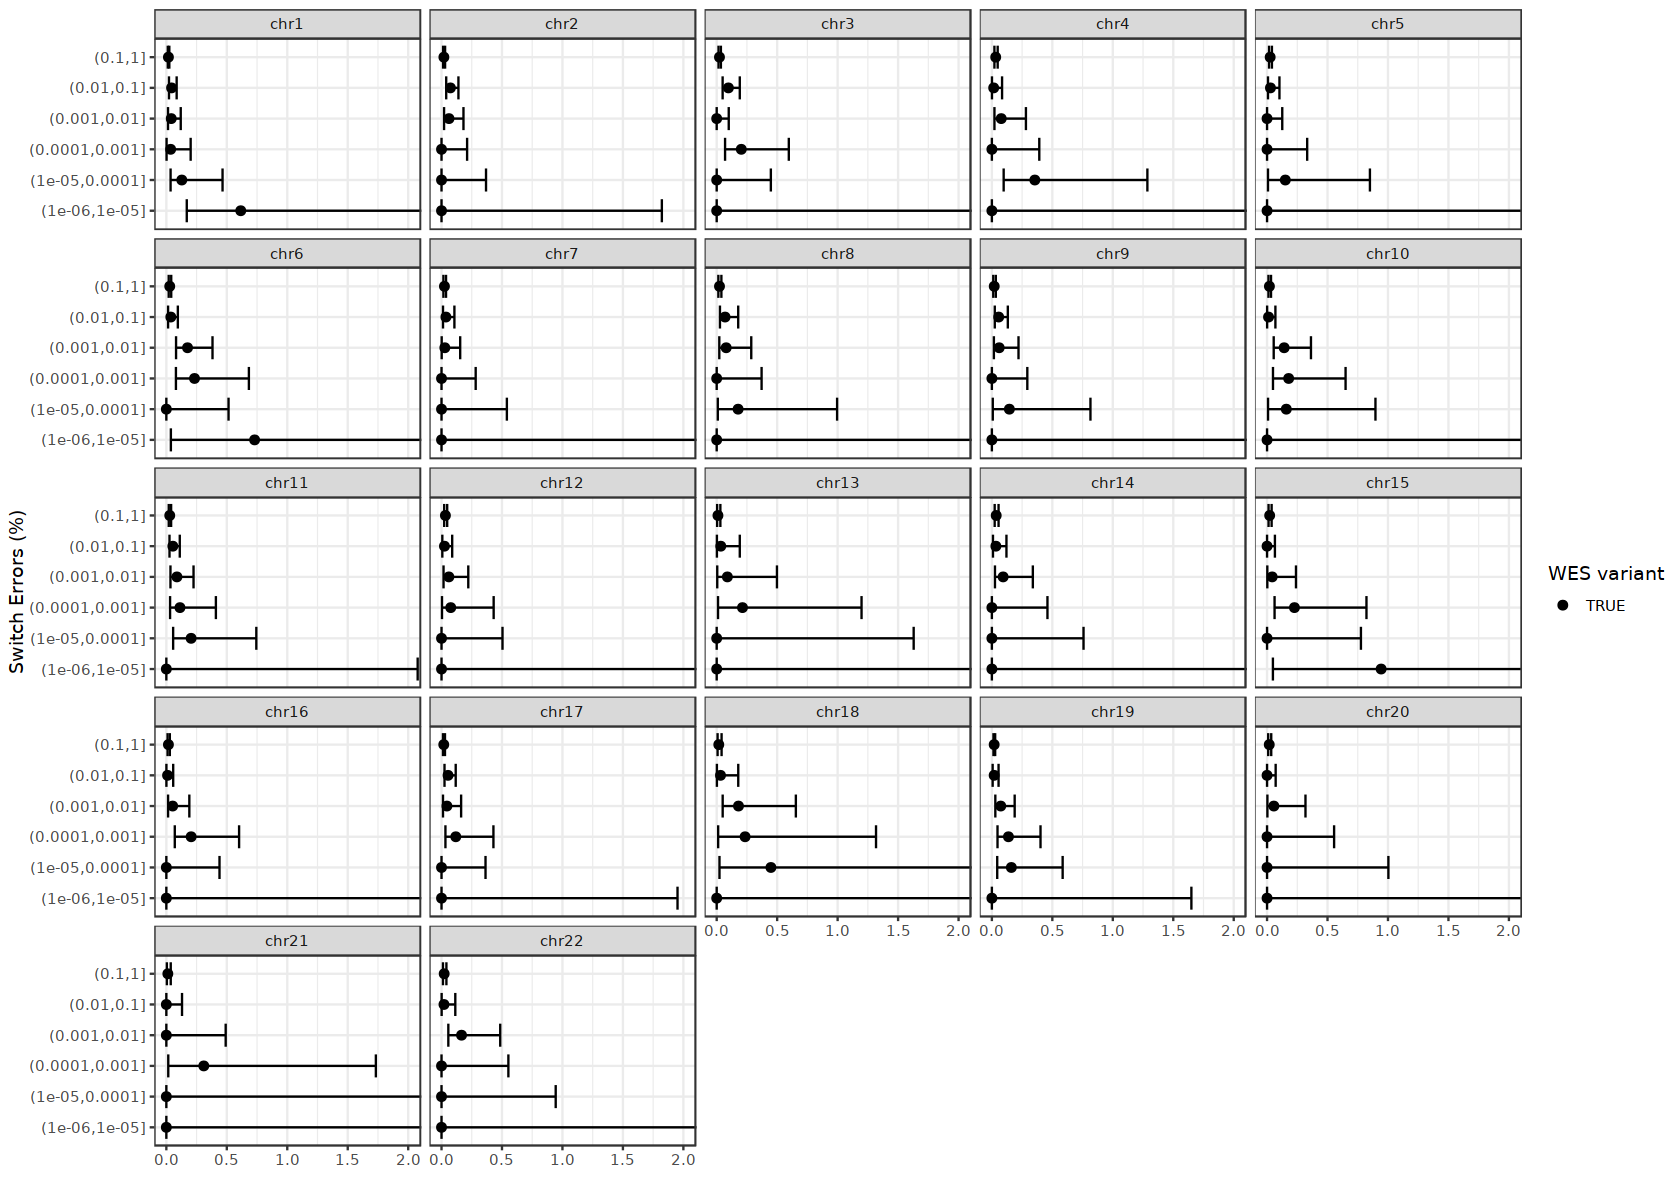

In [225]:
options(repr.plot.width=14, repr.plot.height=10)
plt

In [203]:
lst <- lapply(files, function(file){
    
    d <- fread_phased_sites(file)
    d$wes_variant <- d$locus %in% variants$locus
    d$maf_bin <- cut(d$MAF, breaks = cuts)
    
    # get counts
    counts <- aggregate(switches ~ wes_variant + maf_bin, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + maf_bin, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})

In [204]:
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [205]:
aggr_d <- counts
aggr_switches <- aggregate(switches ~ wes_variant + maf_bin, data = aggr_d, FUN = sum)
aggr_tested <- aggregate(tested ~ wes_variant + maf_bin, data = aggr_d, FUN = sum)
aggr_counts <- data.table(aggr_switches, tested = aggr_tested$tested)


aggr_counts_ci <- do.call(rbind, lapply(1:nrow(aggr_counts), function(i) Hmisc::binconf(aggr_counts$switches[i], aggr_counts$tested[i])))
colnames(aggr_counts_ci) <- tolower(colnames(aggr_counts_ci))
aggr_counts <- cbind(aggr_counts, aggr_counts_ci)

In [206]:
pd <- position_dodge(1)
plt <- ggplot(aggr_counts,
       aes(
           x=100*pointest,
           xmax = 100*upper,
           xmin = 100*lower,
           y = maf_bin,
           fill = factor(wes_variant)
       )) +
    geom_bar(stat = 'identity', position = pd) +
    geom_point(stat='identity', position = pd, size = 2) +
    geom_errorbar(stat='identity', position = pd,width = 0.50) +
    labs(fill = "WES variant") +
    xlab('Switch Errors (%)') + ylab('MAF bin') +
    theme_bw()

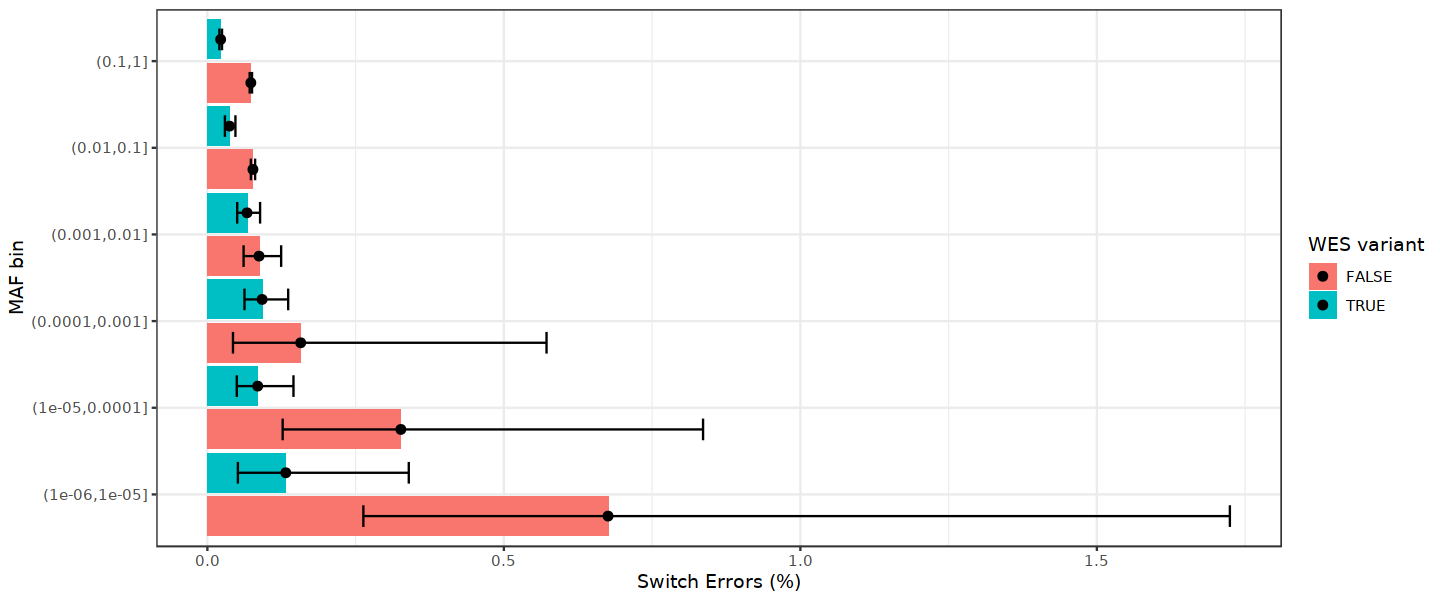

In [207]:
options(repr.plot.width=12, repr.plot.height=5)
plt